In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import corner

# LZ

In [13]:
def plot_corner_LZ(N, plt_range, full=False, Mask=False):
    
    columns = ["Teff", "logg", "[M/H]", "CtoO", "logKzz", "d"]
    data = pd.read_csv(f"./csv/BD{N}_mcmc_LZ.csv"
        , usecols=columns
    )
    
    if full:
        plot_ranges = None
        t16, t50, t84 = np.percentile(data['Teff'], [16, 50, 84], axis=0).round(1)
        g16, g50, g84 = np.percentile(data['logg'], [16, 50, 84], axis=0).round(2)
        m16, m50, m84 = np.percentile(data['[M/H]'], [16, 50, 84], axis=0).round(2)
        c16, c50, c84 = np.percentile(data['CtoO'], [16, 50, 84], axis=0).round(2)
        k16, k50, k84 = np.percentile(data['logKzz'], [16, 50, 84], axis=0).round(2)
        d16, d50, d84 = np.percentile(data['d'], [16, 50, 84], axis=0).round(0)
    else:
        plot_ranges = plt_range
        mask = (data["Teff"] > plt_range[0][0]) & (data["Teff"] < plt_range[0][1]) & \
                (data["logg"] > plt_range[1][0]) & (data["logg"] < plt_range[1][1]) & \
                (data["[M/H]"] > plt_range[2][0]) & (data["[M/H]"] < plt_range[2][1]) & \
                (data["CtoO"] > plt_range[3][0]) & (data["CtoO"] < plt_range[3][1]) & \
                (data["logKzz"] > plt_range[4][0]) & (data["logKzz"] < plt_range[4][1]) & \
                (data["d"] > plt_range[5][0]) & (data["d"] < plt_range[5][1])
        t16, t50, t84 = np.percentile(data[mask]['Teff'], [16, 50, 84], axis=0).round(1)
        g16, g50, g84 = np.percentile(data[mask]['logg'], [16, 50, 84], axis=0).round(2)
        m16, m50, m84 = np.percentile(data[mask]['[M/H]'], [16, 50, 84], axis=0).round(2)
        c16, c50, c84 = np.percentile(data[mask]['CtoO'], [16, 50, 84], axis=0).round(2)
        k16, k50, k84 = np.percentile(data[mask]['logKzz'], [16, 50, 84], axis=0).round(2)
        d16, d50, d84 = np.percentile(data[mask]['d'], [16, 50, 84], axis=0).round(0)
        print(f"Teff: {t16}, {t50}, {t84}")
        print(f"logg: {g16}, {g50}, {g84}")
        print(f"[M/H]: {m16}, {m50}, {m84}")
        print(f"CtoO: {c16}, {c50}, {c84}")
        print(f"logKzz: {k16}, {k50}, {k84}")
        print(f"d: {d16}, {d50}, {d84}")
        if Mask:
            data = data[mask]
        
    
    figure = corner.corner(
        data,
        labels=[
            "Teff",
            "log(g)",
            "[M/H]",
            "C/O",
            r"$\log(K_{zz})$",
            "d",
            r"$\Gamma \, [\mathrm{parsec}]$",
        ],
        quantiles=[0.16, 0.5, 0.84],
        show_titles=True,
        title_kwargs={"fontsize": 12},
        range=plot_ranges
    )
    
    title = f"BD{N}"+"\n"+"Peak beam"+"\n"
    peaks = []
    for i in range(6):
        histo = np.histogram(data[columns[i]], bins=20, range=plt_range[i])
        max_index = np.argmax(histo[0])
        max_value = (histo[1][max_index]+histo[1][max_index+1])/2
        title+="    "+columns[i]+f": {max_value.round(1)} \n"
        peaks.append(max_value.round(1))
    print(f'{peaks[0]},{peaks[1]},{peaks[2]},{peaks[5]},{peaks[3]},{peaks[4]},{t16},{t50},{t84},{g16},{g50},{g84},{m16},{m50},{m84},{d16},{d50},{d84},{c16},{c50},{c84},{k16},{k50},{k84}')
    figure.suptitle(title, x=0.6, ha='left', fontsize=16)
    figure.savefig(f"./png/BD{N}corner_LZ.png")

Teff: 1522.9, 1564.0, 1588.9
logg: 4.04, 4.52, 5.13
[M/H]: -2.02, -1.8, 0.75
CtoO: 0.4, 0.57, 0.77
logKzz: 0.07, 3.51, 7.99
d: 2161.0, 2569.0, 2660.0
1584.5,5.2,-2.0,2607.5,0.5,0.2,1522.9,1564.0,1588.9,4.04,4.52,5.13,-2.02,-1.8,0.75,2161.0,2569.0,2660.0,0.4,0.57,0.77,0.07,3.51,7.99


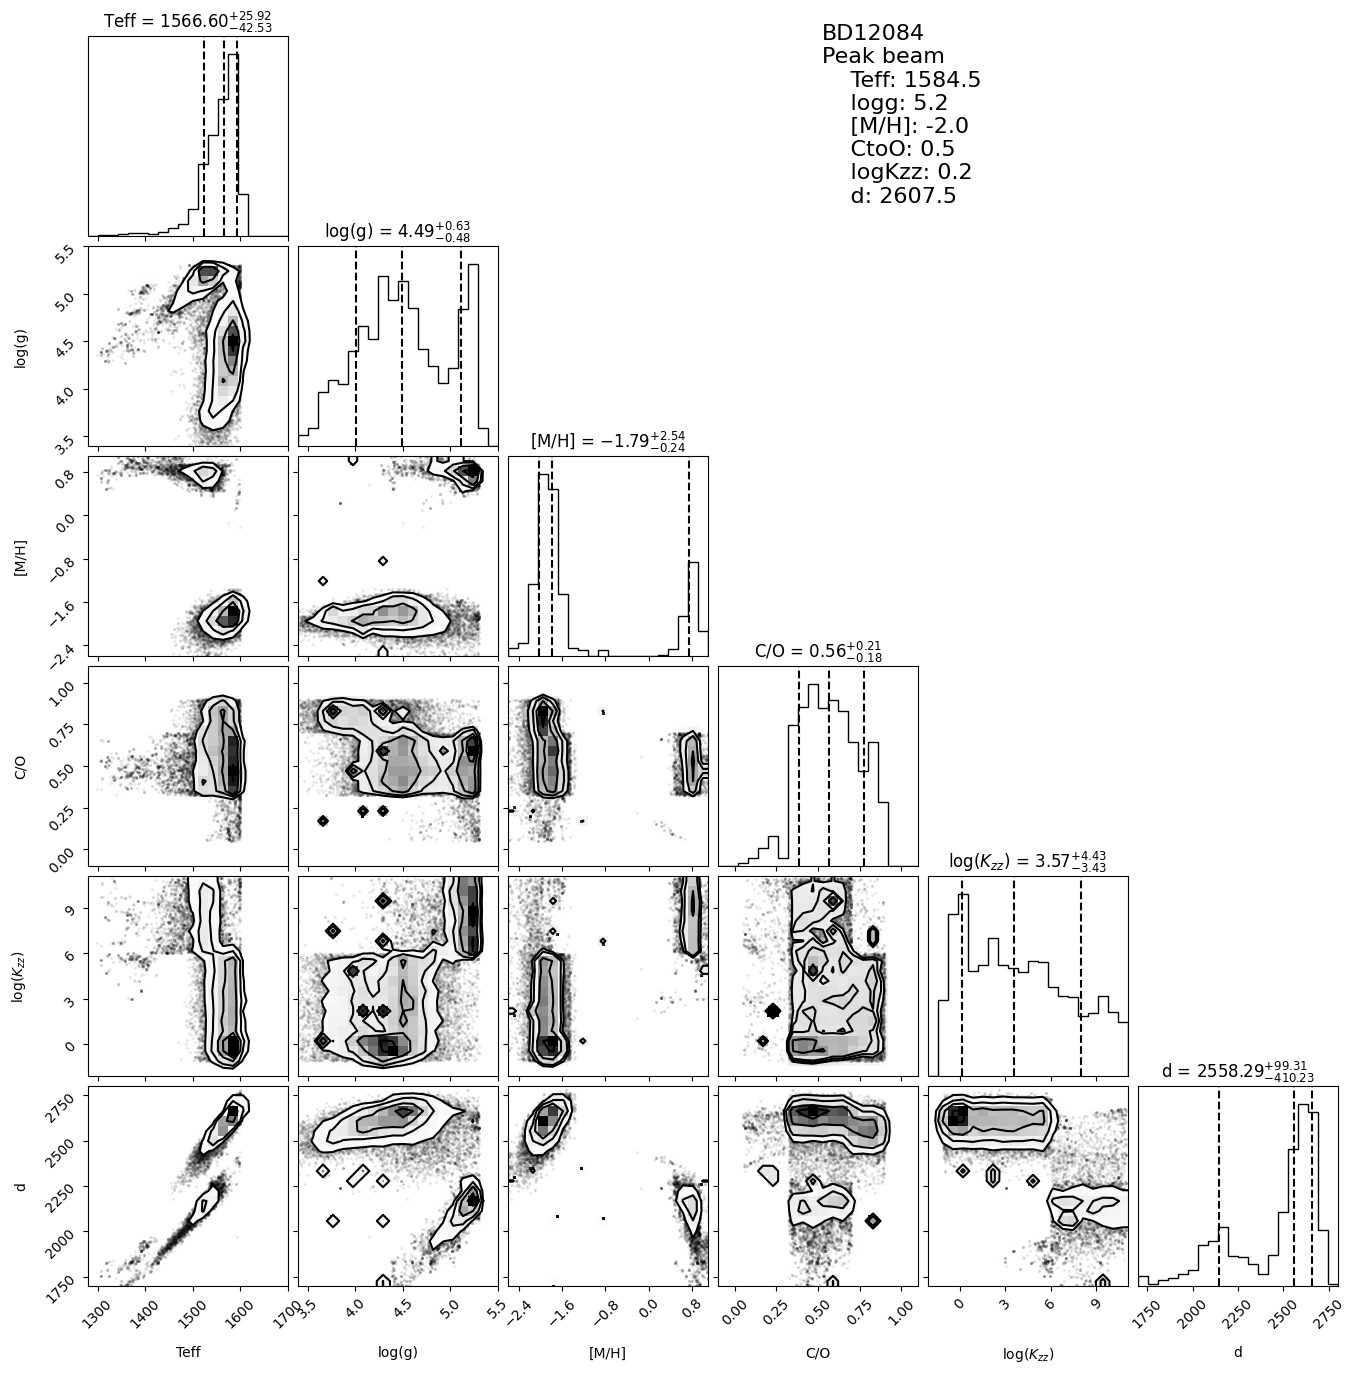

In [38]:
plot_corner_LZ(
    '12084',
    [(1280, 1700), (3.4, 5.5), (-2.6, 1.1),
    (-0.1, 1.1), (-2.1, 11.1), (1700, 2800)],
    # full=True,
    # Mask=True
)

multi peak:
2307
2308
2309
2310
2316
2317
2319
2320
12016
12026
12051
12084

# SB and AT

In [3]:
def plot_corner(N, model, plt_range, full=False, Mask=False):
    
    columns = ["Teff", "log_g", "[M/H]", "d"]
    data = pd.read_csv(f"./csv/BD{N}_mcmc_{model}.csv"
        , usecols=columns
    )
    
    if full:
        plot_ranges = None
        t16, t50, t84 = np.percentile(data['Teff'], [16, 50, 84], axis=0).round(1)
        g16, g50, g84 = np.percentile(data["log_g"], [16, 50, 84], axis=0).round(2)
        m16, m50, m84 = np.percentile(data["[M/H]"], [16, 50, 84], axis=0).round(2)
        d16, d50, d84 = np.percentile(data["d"], [16, 50, 84], axis=0).round(0)
        print(f"{t16},{t50},{t84},{g16},{g50},{g84},{m16},{m50},{m84},{d16},{d50},{d84}")
    else:
        plot_ranges = plt_range
        mask = (data["Teff"] > plt_range[0][0]) & (data["Teff"] < plt_range[0][1]) & \
                (data["log_g"] > plt_range[1][0]) & (data["log_g"] < plt_range[1][1]) & \
                (data["[M/H]"] > plt_range[2][0]) & (data["[M/H]"] < plt_range[2][1]) & \
                (data["d"] > plt_range[3][0]) & (data["d"] < plt_range[3][1])
        # mask = (data["Teff"] >= 400) & (data["Teff"] <= 2000) & \
        #         (data["log_g"] >= 3) & (data["log_g"] <= 5.5) & \
        #         (data["[M/H]"] >= -0.5) & (data["[M/H]"] <= 0.5) & \
        #         (data["d"] > 100) & (data["d"] < 6000)
        t16, t50, t84 = np.percentile(data[mask]['Teff'], [16, 50, 84], axis=0).round(1)
        g16, g50, g84 = np.percentile(data[mask]["log_g"], [16, 50, 84], axis=0).round(2)
        m16, m50, m84 = np.percentile(data[mask]["[M/H]"], [16, 50, 84], axis=0).round(2)
        d16, d50, d84 = np.percentile(data[mask]["d"], [16, 50, 84], axis=0).round(0)
        print(f"{t16},{t50},{t84},{g16},{g50},{g84},{m16},{m50},{m84},{d16},{d50},{d84}")
        # print(f"Teff: {t16},{t50},{t84},")
        # print(f"log(g): {g16},{g50},{g84},")
        # print(f"[M/H]: {m16},{m50},{m84},")
        # print(f"d: {d16},{d50},{d84}")
        if Mask:
            data = data[mask]
        else:
            pass
    
    figure = corner.corner(
        data,
        labels=[
            "Teff",
            "log(g)",
            "[M/H]",
            "d",
            r"$\Gamma \, [\mathrm{parsec}]$",
        ],
        quantiles=[0.16, 0.5, 0.84],
        show_titles=True,
        title_kwargs={"fontsize": 12},
        range=plot_ranges
    )
    
    title = f"BD{N}"+"\n"+"Peak beam"+"\n"
    peaks = []
    for i in range(4):
        histo = np.histogram(data[columns[i]], bins=20, range=plt_range[i])
        max_index = np.argmax(histo[0])
        max_value = (histo[1][max_index]+histo[1][max_index+1])/2
        title+="    "+columns[i]+f": {max_value.round(1)} \n"
        peaks.append(max_value.round(1))
        
    print(f'{peaks[0]},{peaks[1]},{peaks[2]},{peaks[3]},{t16},{t50},{t84},{g16},{g50},{g84},{m16},{m50},{m84},{d16},{d50},{d84}')
    figure.suptitle(title, x=0.6, ha='left', fontsize=16)
    figure.savefig(f"./png/BD{N}corner_{model}.png")

1199.6,1203.8,1208.0,4.87,4.9,4.93,0.27,0.33,0.38,267.0,267.0,267.0
1201.2,4.9,0.4,267.3,1199.6,1203.8,1208.0,4.87,4.9,4.93,0.27,0.33,0.38,267.0,267.0,267.0


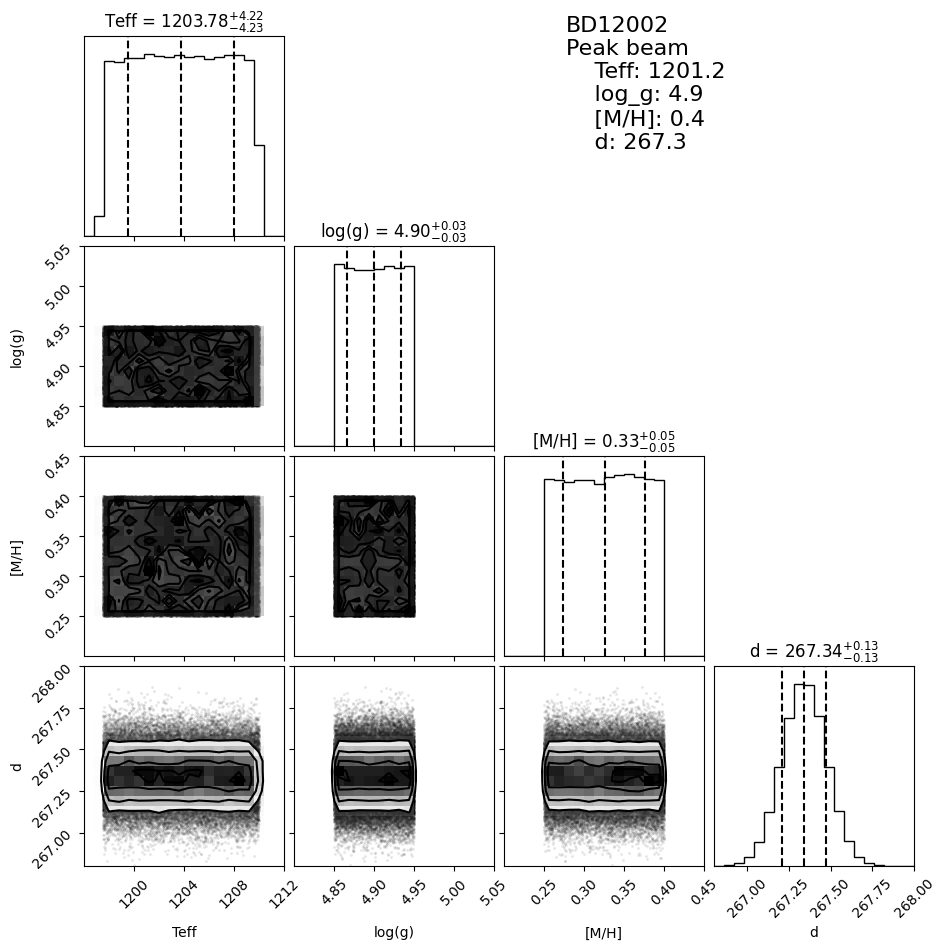

In [13]:
plot_corner(
    '12002', 'AT',
    # [(400, 1200), (2.5, 5.5), (-1, 0.3), (100, 6000)],
    [(1196, 1212), (4.8, 5.05), (0.2, 0.45), (266.8, 268)],
    # full=True,
    # Mask=True
)

multi peak AT
2302
2303
2304
2305